# BioSCape AVIRIS-NG L2A -- Kelp Spectral Analysis

```
BioSCape-AVRISNG_Spectra/
  data/
    rfl_nc/
    rfl_ocean_subset/
  SouthAfricaCoastlineMask/
  outputs/
    manifests/
    scenes/<scene_id>/
      quicklooks/   annotations/   exports/   meta/
    mosaics/   figures/   spectra/
```

## Setup

In [1]:
import sys, importlib
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
from folium.features import GeoJsonTooltip

NC_ALL = Path("Y:/personal/lberberian/Data/Algea/BioSCape/AVRISNG/AVIRISNG_L2")
COASTLINE_SHP = Path("Y:/personal/lberberian/BioSCape/BioSCape-AVRISNG_Spectra/SouthAfricaCoastlineMask/coastl_zaf.shp")

REPO= Path("Y:/personal/lberberian/BioSCape/BioSCape-AVRISNG_Spectra")
DATA = REPO / "data"
RFL_NC = DATA / "rfl_nc"
RFL_SUB  = DATA / "rfl_ocean_subset"
OUTDIR = REPO / "outputs"
MANIFEST = OUTDIR / "manifests"
SCENES = OUTDIR / "scenes"
FIGURES = OUTDIR / "figures"

for p in (RFL_NC, RFL_SUB, OUTDIR, MANIFEST, SCENES, FIGURES,
          OUTDIR/"mosaics", OUTDIR/"spectra"):
    p.mkdir(parents=True, exist_ok=True)

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
import bioscape_rfl_tools as brt
importlib.reload(brt)
print("brt:", brt.__file__)

brt: C:\Users\loriberberian\Desktop\Python\Python_BioSCape\AVRISNG\bioscape_rfl_tools.py


## Discover .nc files

In [2]:
nc_files = brt.list_nc_files(NC_ALL, pattern="*_RFL_ORT.nc")
print(f"found: {len(nc_files)}")

found: 248


## Build footprints and intersect with coastline

In [3]:
coast, coast_union, coast_crs = brt.read_coastline_union(COASTLINE_SHP)
foot_gdf, coast_gdf = brt.build_coast_intersection_gdf(nc_files, COASTLINE_SHP)
print(f"intersects coast: {int(foot_gdf['intersects_coast'].sum())} of {len(foot_gdf)}")

intersects coast: 48 of 248


## Interactive footprint map

In [4]:
foot_ll  = foot_gdf.to_crs(epsg=4326).copy()
coast_ll = coast.to_crs(epsg=4326).copy()
minx, miny, maxx, maxy = foot_ll.total_bounds

m = folium.Map(tiles="OpenStreetMap", control_scale=True)
m.fit_bounds([[miny, minx], [maxy, maxx]])

folium.GeoJson(coast_ll, name="coastline",
    style_function=lambda f: {"color":"red","weight":3,"fill":False}).add_to(m)

tt_fields = [c for c in ["file","intersects_coast","epsg_guess"] if c in foot_ll.columns]
folium.GeoJson(foot_ll, name="footprints",
    style_function=lambda f: {
        "color": "blue" if f["properties"].get("intersects_coast") else "black",
        "weight": 3, "fill": False,
    },
    tooltip=GeoJsonTooltip(fields=tt_fields, sticky=True)).add_to(m)

folium.LayerControl().add_to(m)
m

## Select scenes and write manifests

In [5]:
manual_include = {
    "ang20231109t081408_000_L2A_OE_0b4f48b4_RFL_ORT.nc",
    "ang20231112t081216_002_L2A_OE_0b4f48b4_RFL_ORT.nc",
}
foot_gdf["manual_include"] = foot_gdf["file"].isin(manual_include)
keep_gdf = foot_gdf.loc[foot_gdf["intersects_coast"] | foot_gdf["manual_include"]].copy()
print(f"kept: {len(keep_gdf)} of {len(foot_gdf)}")

keep_paths  = keep_gdf["path"].astype(str).tolist()
keep_stems  = {Path(p).stem for p in keep_paths}
other_paths = [str(p) for p in nc_files if p.stem not in keep_stems]

brt.write_manifest(keep_paths, MANIFEST/"rfl_ocean_subset_manifest.csv",
                   MANIFEST/"rfl_ocean_subset_paths.txt")

kept: 50 of 248
wrote: Y:\personal\lberberian\BioSCape\BioSCape-AVRISNG_Spectra\outputs\manifests\rfl_ocean_subset_manifest.csv
wrote: Y:\personal\lberberian\BioSCape\BioSCape-AVRISNG_Spectra\outputs\manifests\rfl_ocean_subset_paths.txt


## Stage files

In [6]:
brt.stage_files(keep_paths,  RFL_SUB, mode="hardlink")
brt.stage_files(other_paths, RFL_NC,  mode="hardlink")

staged -> Y:\personal\lberberian\BioSCape\BioSCape-AVRISNG_Spectra\data\rfl_ocean_subset  ok:0 skip:50 fail:0
staged -> Y:\personal\lberberian\BioSCape\BioSCape-AVRISNG_Spectra\data\rfl_nc  ok:0 skip:198 fail:0


## Create per-scene folders

In [7]:
nc_paths = sorted(RFL_SUB.glob("*.nc"))
for fn in nc_paths:
    for sub in ("quicklooks", "annotations", "exports", "meta"):
        (SCENES / fn.stem / sub).mkdir(parents=True, exist_ok=True)
print(f"{len(nc_paths)} scene folders ready")

50 scene folders ready


## Export quicklooks (RGB and NDVI)

In [8]:
nc_sub = sorted(RFL_SUB.glob("*.nc"))
metas = brt.batch_export_quicklooks(
    nc_sub, SCENES,
    rgb_wls_nm=(650.0, 560.0, 470.0),
    ndvi_wls_nm=(670.0, 750.0),
    rgb_stretch_p=(2.0, 98.0),
    rgb_valid_range=(0.0, 1.5),
    write_ndvi_u8=True,
    ndvi_u8_mode="fixed",
    ndvi_u8_range=(-0.2, 0.8),
)
metas_df = pd.DataFrame(metas)
metas_df.to_csv(MANIFEST / "quicklook_export_log.csv", index=False)

## Inspect one RGB quicklook

In [9]:
import rasterio
rgb_path = next(SCENES.rglob("*_rgb_u8.tif"))
with rasterio.open(rgb_path) as src:
    arr = src.read()
    print(rgb_path.name, arr.dtype, arr.shape)
    for i in range(3):
        print(f"  band {i+1}: {arr[i].min()} - {arr[i].max()}")

ang20231126t090435_016_L2A_OE_0b4f48b4_RFL_ORT_rgb_u8.tif uint8 (3, 1239, 657)
  band 1: 0 - 255
  band 2: 0 - 255
  band 3: 0 - 255


## Inspect NDVI

ang20231126t090435_016_L2A_OE_0b4f48b4_RFL_ORT_ndvi.tif  valid: 697992/814023 (85.7%)
range: -0.7834 to 0.9147
p2/p50/p98: [-0.16046214  0.35639729  0.79870583]


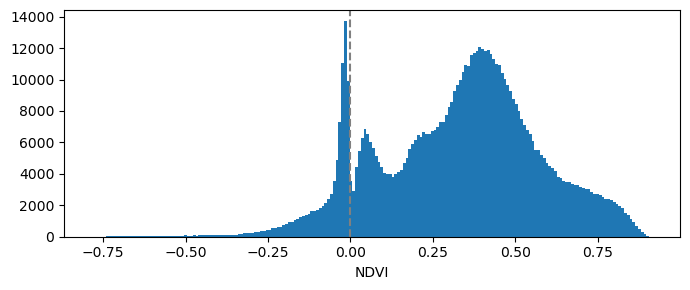

In [10]:
import matplotlib.pyplot as plt

ndvi_path = next(SCENES.rglob("*_ndvi.tif"))
with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1).astype("float32")
    nodata = src.nodata

valid = np.isfinite(ndvi)
if nodata is not None:
    valid &= (ndvi != nodata)
v = ndvi[valid]

print(f"{ndvi_path.name}  valid: {v.size}/{ndvi.size} ({100*v.size/ndvi.size:.1f}%)")
print(f"range: {v.min():.4f} to {v.max():.4f}")
print(f"p2/p50/p98: {np.percentile(v,[2,50,98])}")

plt.figure(figsize=(7,3))
plt.hist(v, bins=200)
plt.axvline(0, ls="--", color="gray")
plt.xlabel("NDVI")
plt.tight_layout()
plt.show()

## Verify CRS: footprint map of all exported scenes

In [11]:
from shapely.geometry import box
from pyproj import Transformer

rows = []
for ndvi_tif in sorted(SCENES.rglob("*_ndvi.tif")):
    with rasterio.open(ndvi_tif) as src:
        epsg = src.crs.to_epsg()
        b = src.bounds
    t = Transformer.from_crs(f"EPSG:{epsg}", "EPSG:4326", always_xy=True)
    lons, lats = t.transform([b.left,b.right,b.right,b.left],
                             [b.bottom,b.bottom,b.top,b.top])
    rows.append({
        "scene_id": ndvi_tif.parent.parent.name,
        "epsg": epsg,
        "crs_south": epsg is not None and 32700 < epsg < 32800,
        "geometry": box(min(lons), min(lats), max(lons), max(lats)),
    })

gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")
print(f"scenes: {len(gdf)}  UTM-South: {gdf['crs_south'].sum()}")

minx, miny, maxx, maxy = gdf.total_bounds
m = folium.Map(tiles="CartoDB positron", control_scale=True)
m.fit_bounds([[miny, minx], [maxy, maxx]])
for _, r in gdf.iterrows():
    coords = list(r["geometry"].exterior.coords)
    folium.Polygon(
        locations=[(lat,lon) for lon,lat in coords],
        color="green" if r["crs_south"] else "red", weight=2,
        fill=True, fill_opacity=0.15,
        tooltip=f"{r['scene_id']}<br>EPSG:{r['epsg']}",
    ).add_to(m)
m

scenes: 50  UTM-South: 50


## Extract kelp spectra

In [ ]:
importlib.reload(brt)
results = brt.batch_extract_kelp_spectra(
    scenes_root=SCENES, rfl_sub=RFL_SUB,
    annotation_glob="*_Kelp.shp",
    ndvi_wls_nm=(670.0, 750.0),
    ndvi_threshold=0.05,
    valid_refl_range=(0.0, 1.5),
)
results_df = pd.DataFrame(results)
print(results_df[["scene_id","n_pixels_in_mask","n_pixels_kept","error"]].to_string(index=False))
results_df.to_csv(MANIFEST / "spectra_extract_log.csv", index=False)

found 18 annotation(s)
  OK   ang20231029t104631_000_L2A_OE_904bad5c_RFL_ORT | 10427 pixels


## Spot-check spectra CSV

In [ ]:
ok = results_df[results_df["error"].isna()]
if ok.empty:
    print("no successful extractions")
else:
    csv_path = Path(ok.iloc[0]["out_csv"])
    df = pd.read_csv(csv_path)
    wl_cols = [c for c in df.columns if c not in ("X","Y","NDVI")]
    print(f"{csv_path.parent.parent.name}: {len(df)} pixels, {len(wl_cols)} bands")
    print(f"NDVI: {df['NDVI'].min():.3f} - {df['NDVI'].max():.3f}")
    df.head()

## Plot spectra for all exported scenes

In [ ]:
import matplotlib.pyplot as plt

export_csvs = sorted(SCENES.rglob("*_spectra.csv"))
print(f"{len(export_csvs)} spectra CSV(s)")

for csv_path in export_csvs:
    scene_id  = csv_path.parent.parent.name
    ndvi_path = SCENES / scene_id / "quicklooks" / f"{scene_id}_ndvi.tif"
    ann_files = list((SCENES/scene_id/"annotations").glob("*_Kelp.shp")) + \
                list((SCENES/scene_id/"annotations").glob("*_kelp.gpkg"))

    df      = pd.read_csv(csv_path)
    wl_cols = [c for c in df.columns if c not in ("X","Y","NDVI")]
    wl      = np.array([float(c) for c in wl_cols])
    spectra = df[wl_cols].values.astype("float32")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(scene_id, fontsize=9, y=1.01)

    ax = axes[0]
    if ndvi_path.exists():
        with rasterio.open(ndvi_path) as src:
            ndvi_arr = src.read(1).astype("float32")
            nodata = src.nodata
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
            scene_crs = src.crs
        if nodata is not None:
            ndvi_arr[ndvi_arr == nodata] = np.nan
        ax.imshow(ndvi_arr, extent=extent, cmap="RdYlGn",
                  vmin=-0.1, vmax=0.8, origin="upper", aspect="equal")
    if ann_files:
        ann = gpd.read_file(ann_files[0]).to_crs(scene_crs)
        ann.boundary.plot(ax=ax, color="white", linewidth=1.5)
    sc = ax.scatter(df["X"], df["Y"], c=df["NDVI"],
                    cmap="RdYlGn", vmin=0, vmax=0.8, s=2)
    plt.colorbar(sc, ax=ax, label="NDVI", fraction=0.03)
    ax.set_title(f"pixels (n={len(df):,})")
    ax.ticklabel_format(style="plain")

    ax2 = axes[1]
    mean_s = np.nanmean(spectra, axis=0)
    std_s  = np.nanstd(spectra, axis=0)
    ax2.plot(wl, mean_s, color="darkgreen", lw=1.5, label="mean")
    ax2.fill_between(wl, mean_s-std_s, mean_s+std_s, alpha=0.25, color="green", label="+/-1 std")
    ax2.set_xlabel("Wavelength (nm)")
    ax2.set_ylabel("Reflectance")
    ax2.set_xlim(wl[0], wl[-1])
    ax2.set_ylim(bottom=0)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES/f"{scene_id}_spectra_check.png", dpi=150, bbox_inches="tight")
    plt.show()